# Projet DataVIZ:
## Analyse des villes les plus attractives pour un investissement immobilier en France

#### Etudiant: Karim CHAMI
#### Mastere 2 AI & Data Science

## Préparation des JDD

### 1. préparer un environnement d'analyse de données

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

### 2. Chargement des jeux de données immobilières et des loyers

# Jeux de données utilisés

Deux jeux de données ont été chargés depuis **data.gouv.fr** :

1. **ValeursFoncieres-2025.txt** : contient les mutations immobilières en France, avec des informations détaillées telles que le prix de vente, la surface du bien, la commune, la nature de la transaction, etc.

2. **pred-mai-mef-dhup.csv** : contient des estimations de loyers au m² par zone géographique.

## Pourquoi avoir choisi ces deux jeux de données ?

Pour un investisseur immobilier, il est essentiel de connaître :

- le coût d'acquisition d'un bien immobilier ;
- les revenus locatifs potentiels qu'il peut générer.

Ces deux jeux de données sont complémentaires :

- **Valeurs Foncières** permet d'analyser les prix d'achat des biens immobiliers ;
- **pred-mai-mef-dhup** permet d'estimer les loyers potentiels selon la localisation.

Le croisement de ces données permet d'évaluer la **rentabilité potentielle d'un investissement immobilier**, en comparant le prix d'achat d'un bien aux revenus locatifs qu'il est susceptible de générer.


In [2]:
# Charger le JDD des valeurs foncières (DVF) de data.gouv.fr
dvf = pd.read_csv(
    "ValeursFoncieres-2025.txt",
    sep="|",
    low_memory=False
)

# Charger le JDD des loyers de data.gouv.fr
loyer = pd.read_csv(
    "pred-mai-mef-dhup.csv",
    sep=";",
    encoding="latin1"
)

In [3]:
# Afficher les dimensions du jeu de données DVF
print("===== DVF =====")
print(dvf.shape)

# Afficher les dimensions du jeu de données des loyers
print("\n===== LOYER =====")
print(loyer.shape)

===== DVF =====
(3714829, 43)

===== LOYER =====
(34900, 13)


In [4]:
# Afficher les 5 premières lignes du jeu de données DVF
dvf.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,Valeur fonciere,No voie,B/T/Q,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,Code commune,Prefixe de section,Section,No plan,No Volume,1er lot,Surface Carrez du 1er lot,2eme lot,Surface Carrez du 2eme lot,3eme lot,Surface Carrez du 3eme lot,4eme lot,Surface Carrez du 4eme lot,5eme lot,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,"468000,00",NaN,NaN,NaN,B078,FARGES,1550.0,FARGES,01,158,NaN,B,815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,78.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,"468000,00",454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,FARGES,01,158,NaN,B,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.0,Dépendance,NaN,0.0,0.0,S,NaN,133.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,07/01/2025,Vente,"468000,00",454.0,NaN,RUE,0090,DE LA REPUBLIQUE,1550.0,FARGES,01,158,NaN,B,910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0,Maison,NaN,111.0,5.0,S,NaN,133.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,"180000,00",NaN,NaN,NaN,B158,LE VILLAGE,1200.0,MONTANGES,01,257,NaN,AC,334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,46.0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,06/01/2025,Vente,"180000,00",NaN,NaN,NaN,B158,LE VILLAGE,1200.0,MONTANGES,01,257,NaN,AC,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,J,NaN,17.0


In [5]:
# Afficher les 5 premières lignes du jeu de données loyer
loyer.head()

,id_zone,INSEE_C,LIBGEO,EPCI,DEP,REG,loypredm2,lwr.IPm2,upr.IPm2,TYPPRED,nbobs_com,nbobs_mail,R2_adj
0,1,37099,Druye,243700754,37,24,"8,95647852540627","6,94544866376119","11,5497949030441",maille,54,494,"0,75527981050117"
1,1,37200,Rivarennes,200072650,37,24,"8,95647852540627","6,94544866376119","11,5497949030441",maille,20,494,"0,75527981050117"
2,1,37264,Vallères,200072650,37,24,"8,95647852540627","6,94544866376119","11,5497949030441",maille,39,494,"0,75527981050117"
3,1,37128,Lignières-de-Touraine,200072650,37,24,"8,95647852540627","6,94544866376119","11,5497949030441",maille,58,494,"0,75527981050117"
4,1,37067,Cheillé,200072650,37,24,"8,95647852540627","6,94544866376119","11,5497949030441",maille,79,494,"0,75527981050117"


In [6]:
# Afficher la structure du jeu de données DVF
# (colonnes, types de données et valeurs non nulles)
dvf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3714829 entries, 0 to 3714828
Data columns (total 43 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Identifiant de document     float64
 1   Reference document          float64
 2   1 Articles CGI              float64
 3   2 Articles CGI              float64
 4   3 Articles CGI              float64
 5   4 Articles CGI              float64
 6   5 Articles CGI              float64
 7   No disposition              int64  
 8   Date mutation               object 
 9   Nature mutation             object 
 10  Valeur fonciere             object 
 11  No voie                     float64
 12  B/T/Q                       object 
 13  Type de voie                object 
 14  Code voie                   object 
 15  Voie                        object 
 16  Code postal                 float64
 17  Commune                     object 
 18  Code departement            object 
 19  Code commune         

In [7]:
# Afficher la structure du jeu de données loyer
# (colonnes, types de données et valeurs non nulles)
loyer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34900 entries, 0 to 34899
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_zone     34900 non-null  object
 1   INSEE_C     34900 non-null  object
 2   LIBGEO      34900 non-null  object
 3   EPCI        34900 non-null  object
 4   DEP         34900 non-null  object
 5   REG         34900 non-null  int64 
 6   loypredm2   34900 non-null  object
 7   lwr.IPm2    34900 non-null  object
 8   upr.IPm2    34900 non-null  object
 9   TYPPRED     34900 non-null  object
 10  nbobs_com   34900 non-null  int64 
 11  nbobs_mail  34900 non-null  int64 
 12  R2_adj      34900 non-null  object
dtypes: int64(3), object(10)
memory usage: 3.5+ MB


In [8]:
# Sélectionner uniquement les colonnes utiles du fichier DVF
dvf = dvf[[
    "Date mutation",
    "Valeur fonciere",
    "Commune",
    "Code departement",
    "Type local",
    "Surface reelle bati",
    "Nombre pieces principales"
]]

# Sélectionner uniquement les colonnes utiles du fichier des loyers
loyer = loyer[[
    "LIBGEO",
    "DEP",
    "REG",
    "loypredm2"
]]

In [9]:
dvf.head()

,Date mutation,Valeur fonciere,Commune,Code departement,Type local,Surface reelle bati,Nombre pieces principales
0,07/01/2025,"468000,00",FARGES,01,NaN,NaN,NaN
1,07/01/2025,"468000,00",FARGES,01,Dépendance,0.0,0.0
2,07/01/2025,"468000,00",FARGES,01,Maison,111.0,5.0
3,06/01/2025,"180000,00",MONTANGES,01,NaN,NaN,NaN
4,06/01/2025,"180000,00",MONTANGES,01,NaN,NaN,NaN


In [10]:
loyer.head()

,LIBGEO,DEP,REG,loypredm2
0,Druye,37,24,"8,95647852540627"
1,Rivarennes,37,24,"8,95647852540627"
2,Vallères,37,24,"8,95647852540627"
3,Lignières-de-Touraine,37,24,"8,95647852540627"
4,Cheillé,37,24,"8,95647852540627"


In [11]:
# Remplacer les virgules par des points dans la colonne des valeurs foncières
dvf["Valeur fonciere"] = (
    dvf["Valeur fonciere"]
    .astype(str)
    .str.replace(",", ".")
)

# Convertir la colonne en type numérique
dvf["Valeur fonciere"] = pd.to_numeric(
    dvf["Valeur fonciere"],
    errors="coerce"
)

In [12]:
# Remplacer les virgules par des points dans la colonne du loyer au m²
loyer["loypredm2"] = (
    loyer["loypredm2"]
    .astype(str)
    .str.replace(",", ".")
)

# Convertir la colonne en type numérique
loyer["loypredm2"] = pd.to_numeric(
    loyer["loypredm2"],
    errors="coerce"
)

In [13]:
dvf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3714829 entries, 0 to 3714828
Data columns (total 7 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Date mutation              object 
 1   Valeur fonciere            float64
 2   Commune                    object 
 3   Code departement           object 
 4   Type local                 object 
 5   Surface reelle bati        float64
 6   Nombre pieces principales  float64
dtypes: float64(3), object(4)
memory usage: 198.4+ MB


In [14]:
loyer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34900 entries, 0 to 34899
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   LIBGEO     34900 non-null  object 
 1   DEP        34900 non-null  object 
 2   REG        34900 non-null  int64  
 3   loypredm2  34900 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ MB


In [15]:
# Afficher le nombre de valeurs manquantes par colonne dans DVF
print(dvf.isna().sum())

Date mutation                      0
Valeur fonciere                48420
Commune                            0
Code departement                   0
Type local                   1469244
Surface reelle bati          1471349
Nombre pieces principales    1471349
dtype: int64


In [16]:
# Afficher le nombre de valeurs manquantes par colonne dans loyer
print(loyer.isna().sum())

LIBGEO       0
DEP          0
REG          0
loypredm2    0
dtype: int64


In [17]:
print( dvf["Type local"].unique())

[nan 'Dépendance' 'Maison' 'Appartement'
 'Local industriel. commercial ou assimilé']


In [18]:
# Filtrer le jeu de données pour ne garder que les appartements et maisons
dvf = dvf[
    dvf["Type local"].isin([
        "Appartement",
        "Maison"
    ])
]

In [19]:
# Compter le nombre d'occurrences de chaque type de bien
dvf["Type local"].value_counts()

Type local
Maison         619955
Appartement    512979
Name: count, dtype: int64

In [20]:
# Supprimer les lignes où la valeur foncière ou la surface est manquante
dvf = dvf.dropna(subset=[
    "Valeur fonciere",
    "Surface reelle bati"
])

In [21]:
dvf.shape

(1122389, 7)

In [22]:
# Créer une nouvelle colonne : prix au m²
dvf["prix_m2"] = (
    dvf["Valeur fonciere"] /
    dvf["Surface reelle bati"]
)

In [23]:
dvf["prix_m2"].describe()

count    1.122389e+06
mean     1.788748e+04
std      1.726751e+05
min      1.379310e-03
25%      1.730769e+03
50%      2.740292e+03
75%      4.560377e+03
max      3.159091e+07
Name: prix_m2, dtype: float64

In [24]:
# Le prix médian est de 2 740 €/m².
# La moyenne (17 887 €/m²) est fortement influencée par des valeurs extrêmes.
# La présence d'outliers est confirmée par le maximum très élevé (31,6 M€/m²).

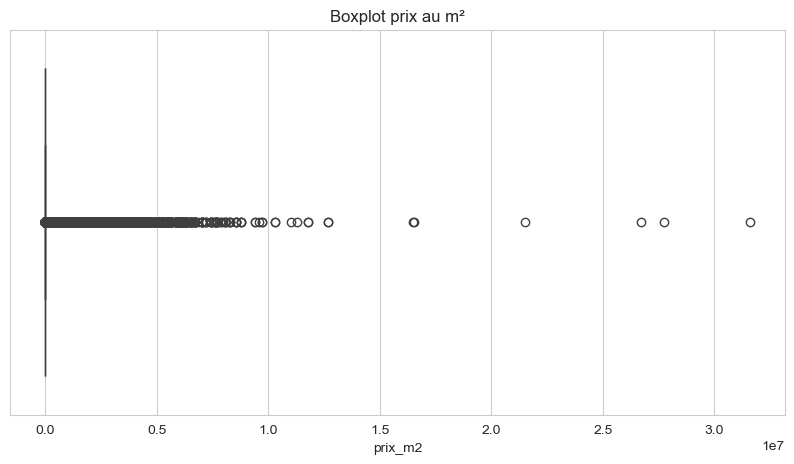

In [25]:
plt.figure(figsize=(10,5))

sns.boxplot(x=dvf["prix_m2"])

plt.title("Boxplot prix au m²")
plt.show()

In [26]:
# Le boxplot met en évidence de nombreux outliers avec des prix au m² extrêmement élevés.
# Ces valeurs compressent la boîte près de 0 et rendent la distribution difficile à lire.
# Un filtrage des valeurs aberrantes est nécessaire avant l'analyse.

#La présence de valeurs extrêmes est observée, avec des prix au m² pouvant atteindre plusieurs millions d'euros.

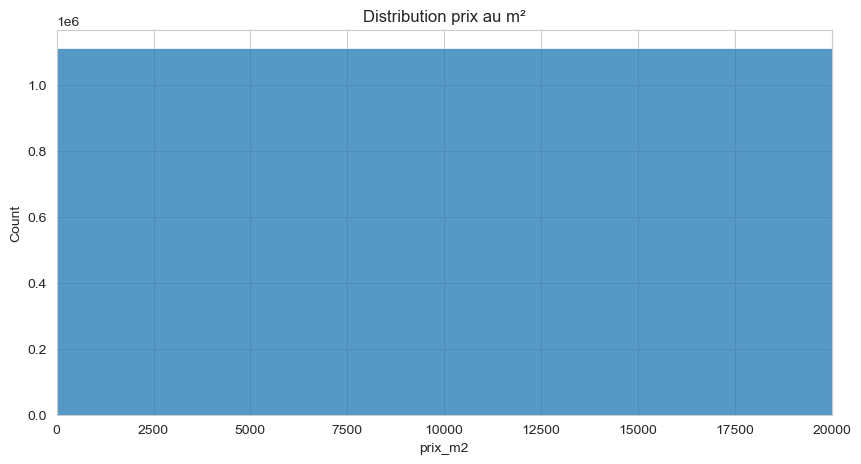

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(dvf["prix_m2"], bins=100)

plt.xlim(0, 20000)

plt.title("Distribution prix au m²")
plt.show()

In [28]:
#appliquer un filtre métier

In [29]:
avant = len(dvf)

dvf_filtre = dvf[
    (dvf["prix_m2"] >= 500) &
    (dvf["prix_m2"] <= 20000)
]

apres = len(dvf_filtre)

print(f"Lignes supprimées : {avant - apres:,}")
print(f"Pourcentage supprimé : {(avant - apres)/avant*100:.2f}%")

Lignes supprimées : 82,840
Pourcentage supprimé : 7.38%


In [30]:
dvf = dvf[
    (dvf["prix_m2"] >= 500) &
    (dvf["prix_m2"] <= 20000)
]

In [31]:
dvf["prix_m2"].describe()

count    1.039549e+06
mean     3.548977e+03
std      2.878405e+03
min      5.000000e+02
25%      1.759657e+03
50%      2.689394e+03
75%      4.228605e+03
max      2.000000e+04
Name: prix_m2, dtype: float64

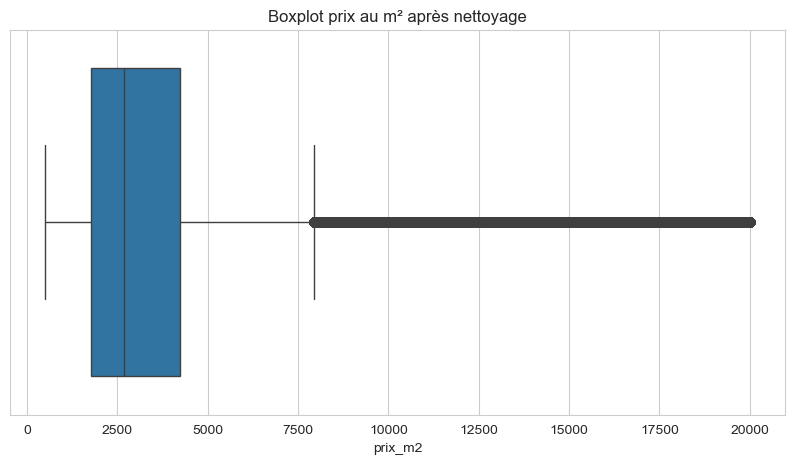

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(x=dvf["prix_m2"])

plt.title("Boxplot prix au m² après nettoyage")
plt.show()

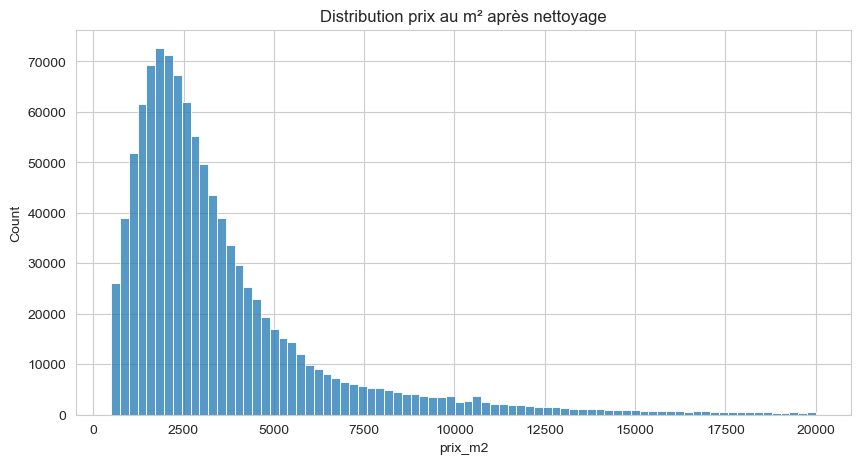

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(dvf["prix_m2"], bins=80)
plt.title("Distribution prix au m² après nettoyage")
plt.show()

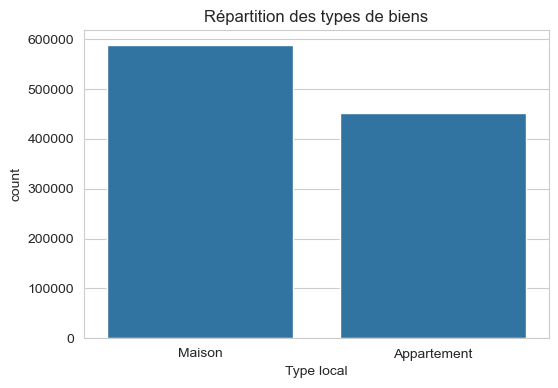

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(data=dvf, x="Type local")
plt.title("Répartition des types de biens")
plt.show()

In [35]:
dvf.groupby("Type local")["prix_m2"].mean()

Type local
Appartement    4572.125942
Maison         2763.708431
Name: prix_m2, dtype: float64

In [36]:
# Agrégation des données par commune
ville_stats = (
    dvf.groupby("Commune")
    .agg({
        "prix_m2": ["mean", "count"]
    })
)

# Renommage des colonnes
ville_stats.columns = [
    "prix_m2_moyen",
    "nb_transactions"
]

# Réinitialisation de l'index
ville_stats = ville_stats.reset_index()

In [37]:
# Filtrage des communes avec au moins 30 transactions
ville_stats = ville_stats[
    ville_stats["nb_transactions"] >= 30
]

In [38]:
# Sélection des 10 communes les plus chères
top_chere = (
    ville_stats
    .sort_values(
        by="prix_m2_moyen",
        ascending=False
    )
    .head(10)
)

# Affichage du résultat
top_chere

,Commune,prix_m2_moyen,nb_transactions
18589,PARIS 06,13598.670048,693
18590,PARIS 07,13215.325144,847
22499,SAINT-JEAN-CAP-FERRAT,12924.250468,30
18587,PARIS 04,12597.872317,549
26845,VAL-D ISERE,12507.624973,82
21555,SAINT TROPEZ,12414.862489,133
18584,PARIS 01,12098.233693,277
18586,PARIS 03,11890.462510,736
18588,PARIS 05,11765.324275,926
18591,PARIS 08,11734.456102,668


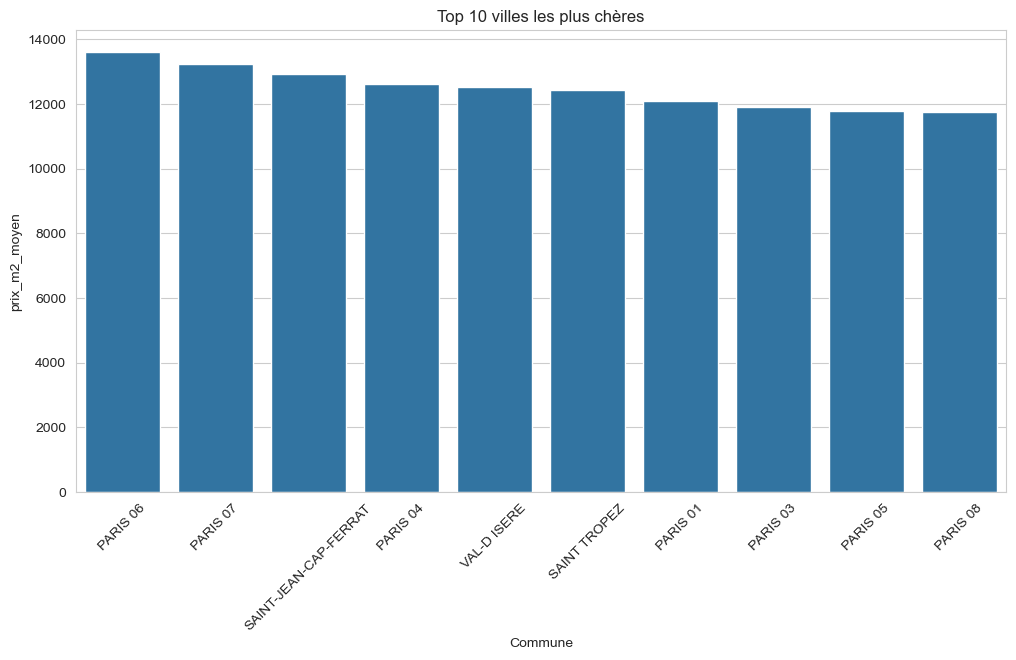

In [39]:
# Création du graphique
plt.figure(figsize=(12,6))

# Construction du diagramme en barres
sns.barplot(
    data=top_chere,
    x="Commune",
    y="prix_m2_moyen"
)

# Rotation des étiquettes de l'axe X
plt.xticks(rotation=45)

# Ajout du titre
plt.title("Top 10 villes les plus chères")

# Affichage du graphique
plt.show()

In [40]:
# Normalisation des noms de communes dans le fichier DVF
dvf["Commune"] = (
    dvf["Commune"]
    .str.upper()
    .str.strip()
)

# Normalisation des noms de communes dans le fichier des loyers
loyer["LIBGEO"] = (
    loyer["LIBGEO"]
    .str.upper()
    .str.strip()
)

In [41]:
# Agrégation des données immobilières par ville et département
prix_ville = (
    dvf.groupby([
        "Commune",
        "Code departement"
    ])
    .agg({
        "prix_m2": "mean",
        "Valeur fonciere": "count"
    })
    .reset_index()
)

# Renommage des colonnes
prix_ville.columns = [
    "ville",
    "departement",
    "prix_m2",
    "nb_transactions"
]

In [42]:
prix_ville.head()

,ville,departement,prix_m2,nb_transactions
0,AAST,64,986.821705,2
1,ABAINVILLE,55,776.456140,5
2,ABANCOURT,59,1477.869028,19
3,ABANCOURT,60,1498.572699,8
4,ABAUCOURT,54,1498.916254,7


In [43]:
# Affichage des dimensions du DataFrame
prix_ville.shape

(30491, 4)

In [44]:
# Filtrage des communes avec au moins 30 transactions
prix_ville= prix_ville[
    prix_ville["nb_transactions"] >= 30
]

In [45]:
# Affichage des dimensions du DataFrame
prix_ville.shape

(5856, 4)

In [46]:
prix_ville.head()

,ville,departement,prix_m2,nb_transactions
6,ABBARETZ,44,1749.354128,30
10,ABBEVILLE,80,2105.698107,335
31,ABLIS,78,2602.416398,32
33,ABLON-SUR-SEINE,94,3279.097672,61
36,ABONDANCE,74,4399.576642,43


In [47]:
loyer = loyer.rename(columns={
    "LIBGEO": "ville",
    "DEP": "departement"
})

In [48]:
loyer.head()

,ville,departement,REG,loypredm2
0,DRUYE,37,24,8.956479
1,RIVARENNES,37,24,8.956479
2,VALLÈRES,37,24,8.956479
3,LIGNIÈRES-DE-TOURAINE,37,24,8.956479
4,CHEILLÉ,37,24,8.956479


In [49]:
#jointure entre dvf et loyer
df = prix_ville.merge(
    loyer,
    on=["ville", "departement"],
    how="inner"
)

In [50]:
df.shape

(3781, 6)

In [51]:
df.head()

,ville,departement,prix_m2,nb_transactions,REG,loypredm2
0,ABBARETZ,44,1749.354128,30,52,8.814289
1,ABBEVILLE,80,2105.698107,335,32,8.832116
2,ABLIS,78,2602.416398,32,11,10.593604
3,ABLON-SUR-SEINE,94,3279.097672,61,11,16.226343
4,ABONDANCE,74,4399.576642,43,84,14.455576


In [52]:
# Définition d'une surface de référence
surface_moyenne = 50

In [53]:
# Estimation du prix d'un logement de 50 m²
df["prix_estime"] = (
    df["prix_m2"] *
    surface_moyenne
)

In [54]:
# Estimation du prix annuel
df["loyer_annuel"] = (
    df["loypredm2"] *
    surface_moyenne *
    12
)

In [55]:
df["rendement_brut"] = (
    df["loyer_annuel"] /
    df["prix_estime"]
) * 100

In [56]:
df[[
    "ville",
    "prix_m2",
    "loypredm2",
    "rendement_brut"
]].head()

,ville,prix_m2,loypredm2,rendement_brut
0,ABBARETZ,1749.354128,8.814289,6.046315
1,ABBEVILLE,2105.698107,8.832116,5.033266
2,ABLIS,2602.416398,10.593604,4.884816
3,ABLON-SUR-SEINE,3279.097672,16.226343,5.938101
4,ABONDANCE,4399.576642,14.455576,3.942809


In [57]:
df["rendement_brut"].describe()

count    3781.000000
mean        4.728920
std         1.189919
min         1.018467
25%         3.974863
50%         4.734093
75%         5.454249
max        13.303351
Name: rendement_brut, dtype: float64

In [58]:
df_rentable = df[
    df["nb_transactions"] >= 50
]

In [59]:
top_renta = (
    df_rentable
    .sort_values(
        by="rendement_brut",
        ascending=False
    )
    .head(15)
)

top_renta[[
    "ville",
    "departement",
    "prix_m2",
    "loypredm2",
    "rendement_brut"
]]

,ville,departement,prix_m2,loypredm2,rendement_brut
1323,GRIGNY,91,1634.606153,15.579072,11.436936
1632,LAPALISSE,03,1198.432113,8.690008,8.701377
2910,SAINT-CLAUDE,39,1673.055414,11.934741,8.560200
1297,GRAND-CHARMONT,25,1376.868591,9.711803,8.464253
1424,IMPHY,58,1169.681357,7.868165,8.072112
3547,VARENNES-VAUZELLES,58,1648.366714,11.003700,8.010621
1606,LANGEAC,43,1162.390229,7.686596,7.935300
1020,DOUCHY-LES-MINES,59,1415.868079,9.127959,7.736279
405,BOHAIN-EN-VERMANDOIS,02,1109.132986,7.109079,7.691498
783,CHEF-BOUTONNE,79,1211.723812,7.691186,7.616772


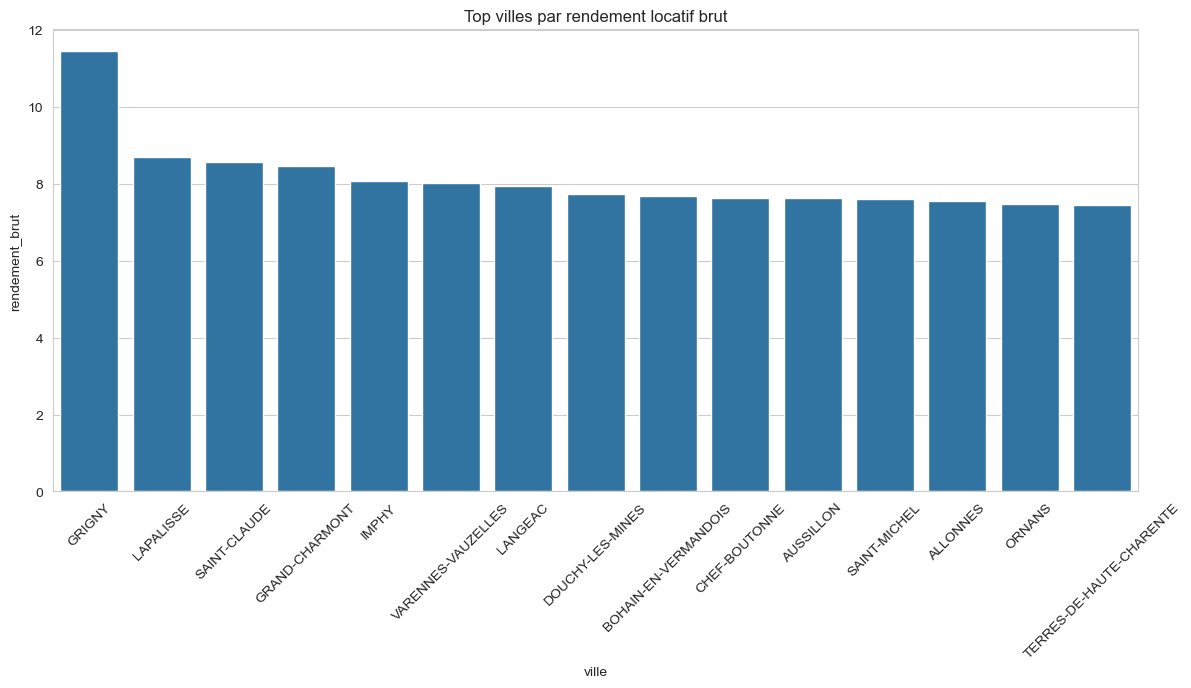

In [60]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_renta,
    x="ville",
    y="rendement_brut"
)

plt.xticks(rotation=45)

plt.title("Top villes par rendement locatif brut")

plt.show()

In [61]:
corr = df[[
    "prix_m2",
    "loypredm2",
    "rendement_brut",
    "nb_transactions"
]].corr()

corr

,prix_m2,loypredm2,rendement_brut,nb_transactions
prix_m2,1.000000,0.691399,-0.698471,0.184197
loypredm2,0.691399,1.000000,-0.114075,0.218371
rendement_brut,-0.698471,-0.114075,1.000000,-0.089139
nb_transactions,0.184197,0.218371,-0.089139,1.000000


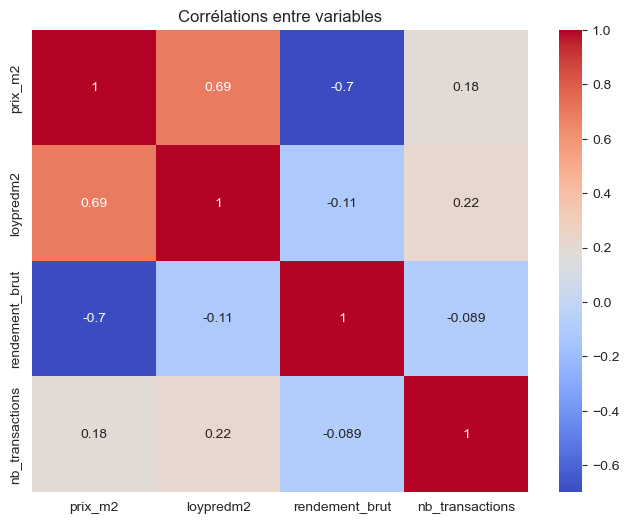

In [62]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Corrélations entre variables")

plt.show()

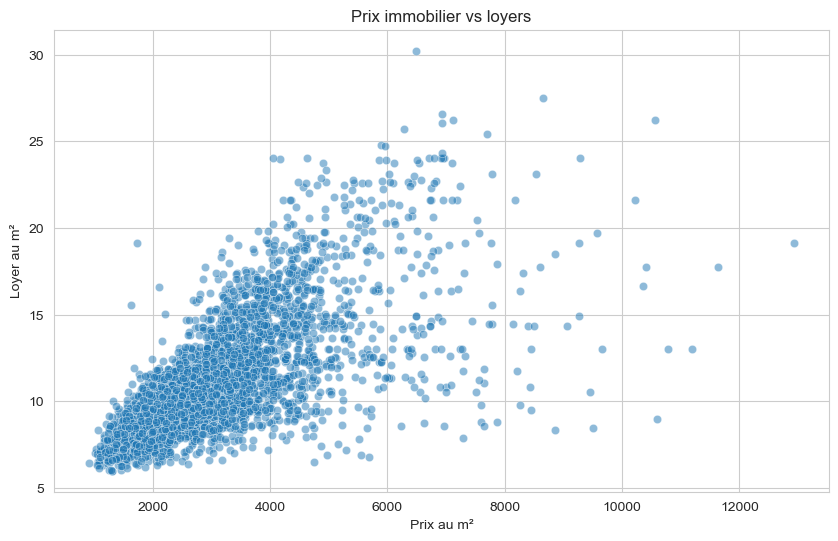

In [63]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="prix_m2",
    y="loypredm2",
    alpha=0.5
)

plt.title("Prix immobilier vs loyers")

plt.xlabel("Prix au m²")
plt.ylabel("Loyer au m²")

plt.show()

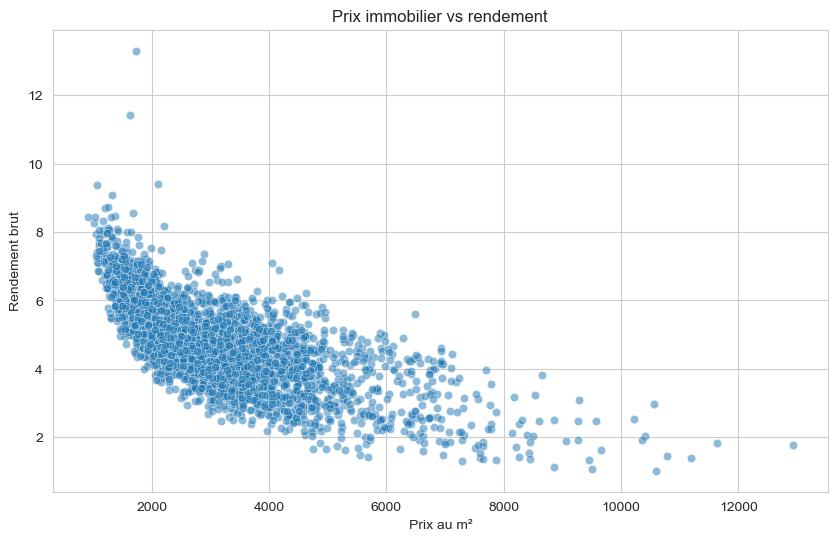

In [64]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="prix_m2",
    y="rendement_brut",
    alpha=0.5
)

plt.title("Prix immobilier vs rendement")

plt.xlabel("Prix au m²")
plt.ylabel("Rendement brut")

plt.show()

In [65]:
region_stats = (
    df.groupby("REG")
    .agg({
        "rendement_brut":"mean"
    })
    .sort_values(
        by="rendement_brut",
        ascending=False
    )
)

region_stats

,rendement_brut
REG,
2,6.093496
3,5.403728
1,5.339542
44,5.310577
27,5.250838
24,5.244807
32,5.057333
11,4.971167
4,4.839842


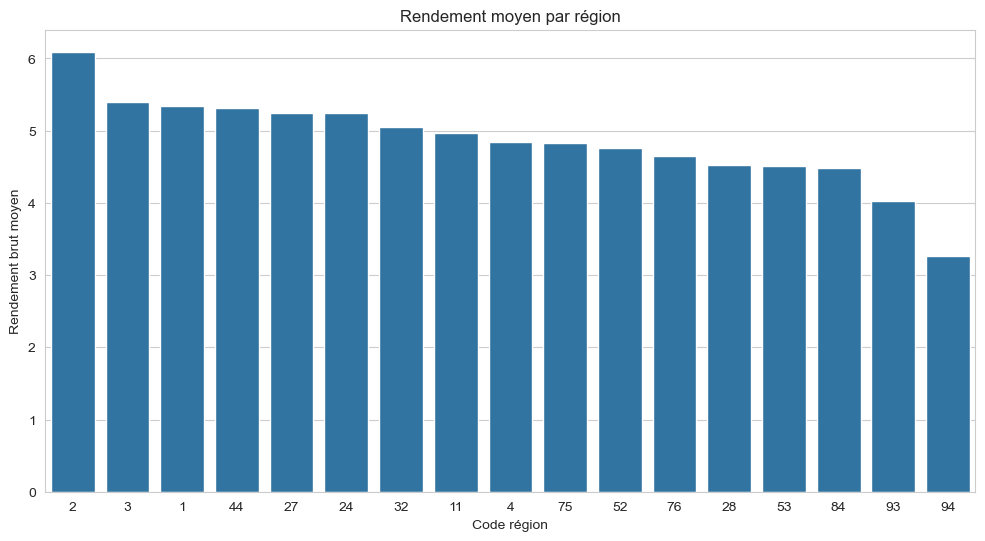

In [66]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=region_stats.index.astype(str),
    y=region_stats["rendement_brut"]
)

plt.title("Rendement moyen par région")

plt.xlabel("Code région")
plt.ylabel("Rendement brut moyen")

plt.show()

In [67]:
corr_coef, p_value = pearsonr(
    df["prix_m2"],
    df["loypredm2"]
)

print("Coefficient de corrélation :", corr_coef)
print("P-value :", p_value)

Coefficient de corrélation : 0.6913985559623603
P-value : 0.0


In [68]:
corr_coef2, p_value2 = pearsonr(
    df["prix_m2"],
    df["rendement_brut"]
)

print("Coefficient :", corr_coef2)
print("P-value :", p_value2)

Coefficient : -0.698471351161996
P-value : 0.0


In [69]:
appart = dvf[
    dvf["Type local"] == "Appartement"
]["prix_m2"]

maison = dvf[
    dvf["Type local"] == "Maison"
]["prix_m2"]

t_stat, p_value = ttest_ind(
    appart,
    maison,
    equal_var=False
)

print("T-stat :", t_stat)
print("P-value :", p_value)

T-stat : 315.11687657796006
P-value : 0.0


In [70]:
df.columns

Index(['ville', 'departement', 'prix_m2', 'nb_transactions', 'REG',
       'loypredm2', 'prix_estime', 'loyer_annuel', 'rendement_brut'],
      dtype='object')

In [71]:
df["categorie_rendement"] = pd.cut(
    df["rendement_brut"],
    bins=[0, 3, 5, 7, 20],
    labels=[
        "Faible",
        "Moyen",
        "Bon",
        "Excellent"
    ]
)

In [72]:
df["score_investissement"] = (
    df["rendement_brut"] *
    df["nb_transactions"]
) / df["prix_m2"]

In [73]:
regions = {
    11: "Île-de-France",
    24: "Centre-Val de Loire",
    27: "Bourgogne-Franche-Comté",
    28: "Normandie",
    32: "Hauts-de-France",
    44: "Grand Est",
    52: "Pays de la Loire",
    53: "Bretagne",
    75: "Nouvelle-Aquitaine",
    76: "Occitanie",
    84: "Auvergne-Rhône-Alpes",
    93: "Provence-Alpes-Côte d’Azur",
    94: "Corse",
    1: "Guadeloupe",
    2: "Martinique",
    3: "Guyane",
    4: "La Réunion"
}

df["nom_region"] = df["REG"].map(regions)

In [74]:
df = df.rename(columns={
  "loypredm2": "loyer_m2",
    "nb_transactions": "nombre_transactions"
})

In [75]:
df = df.rename(columns={
    "REG": "code_region"
})

In [76]:
df = df[
    (df["nombre_transactions"] >= 30) &
    (df["categorie_rendement"].notna())
]
df = df[[
    "ville",
    "departement",
    "code_region",
    "nom_region",
    
    "prix_m2",
    "prix_estime",
    
    "loyer_m2",
    "loyer_annuel",
    
    "rendement_brut",
    "categorie_rendement",
    "score_investissement",
    
    "nombre_transactions"
]]

In [77]:
print(df["categorie_rendement"].unique())

['Bon', 'Moyen', 'Faible', 'Excellent']
Categories (4, object): ['Faible' < 'Moyen' < 'Bon' < 'Excellent']


In [78]:
print("Minimum :", df["nombre_transactions"].min())
print("Maximum :", df["nombre_transactions"].max())

Minimum : 30
Maximum : 8841


In [79]:
df["departement"] = df["departement"].astype(str).str.zfill(2)

In [80]:
df["ville"] = df["ville"].str.strip().str.title()

In [81]:
df.head()

,ville,departement,code_region,nom_region,prix_m2,prix_estime,loyer_m2,loyer_annuel,rendement_brut,categorie_rendement,score_investissement,nombre_transactions
0,Abbaretz,44,52,Pays de la Loire,1749.354128,87467.706413,8.814289,5288.573423,6.046315,Bon,0.103689,30
1,Abbeville,80,32,Hauts-de-France,2105.698107,105284.905356,8.832116,5299.269419,5.033266,Bon,0.800753,335
2,Ablis,78,11,Île-de-France,2602.416398,130120.819895,10.593604,6356.162211,4.884816,Moyen,0.060065,32
3,Ablon-Sur-Seine,94,11,Île-de-France,3279.097672,163954.883585,16.226343,9735.806061,5.938101,Bon,0.110465,61
4,Abondance,74,84,Auvergne-Rhône-Alpes,4399.576642,219978.832086,14.455576,8673.345536,3.942809,Moyen,0.038536,43


## Formulation et Test des hypothèses.

## Test ANOVA

In [82]:
from scipy.stats import f_oneway

# Création des groupes par région
groupes = [g["rendement_brut"].dropna() for _, g in df.groupby("nom_region")]

# Test ANOVA
f_stat, p_value = f_oneway(*groupes)

print("===== TEST ANOVA =====")
print("F-statistic :", round(f_stat, 4))
print("p-value :", p_value)

===== TEST ANOVA =====
F-statistic : 22.2525
p-value : 8.469303238013355e-63


## Graphique ANOVA

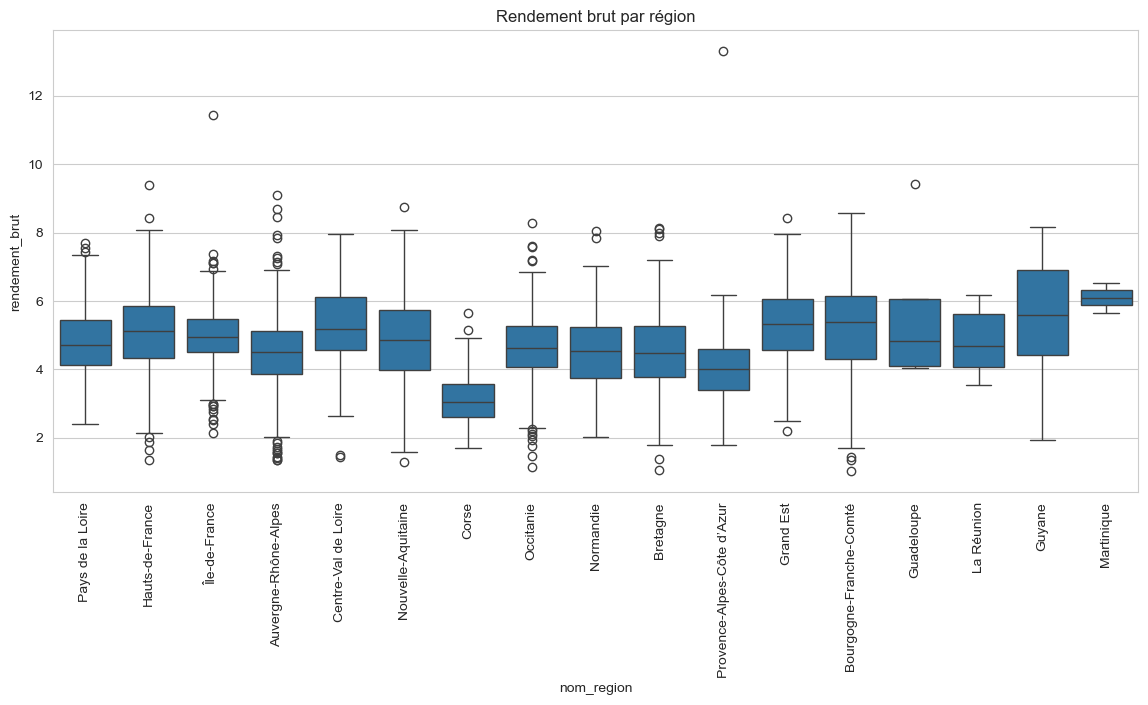

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x="nom_region",
    y="rendement_brut"
)

plt.xticks(rotation=90)
plt.title("Rendement brut par région")
plt.show()

## Test du Chi²


In [84]:
from scipy.stats import chi2_contingency
import pandas as pd

# Tableau de contingence
table_contingence = pd.crosstab(
    df["nom_region"],
    df["categorie_rendement"]
)

print("Tableau de contingence :")
print(table_contingence)

# Test du Chi²
chi2, p_value, ddl, expected = chi2_contingency(table_contingence)

print("\n===== TEST DU CHI² =====")
print("Chi² :", round(chi2, 4))
print("Degrés de liberté :", ddl)
print("p-value :", p_value)

Tableau de contingence :
categorie_rendement         Faible  Moyen  Bon  Excellent
nom_region                                               
Auvergne-Rhône-Alpes            52    348  157          9
Bourgogne-Franche-Comté         11     51   84         18
Bretagne                        30    191   97          9
Centre-Val de Loire              4     67   99         11
Corse                           13     11    2          0
Grand Est                        3     42   64          9
Guadeloupe                       0      5    3          1
Guyane                           1      1    2          1
Hauts-de-France                 21    144  176         21
La Réunion                       0      5    5          0
Martinique                       0      0    2          0
Normandie                       26    152   88          4
Nouvelle-Aquitaine              38    200  195         16
Occitanie                       15    250  134          5
Pays de la Loire                14    119   91 

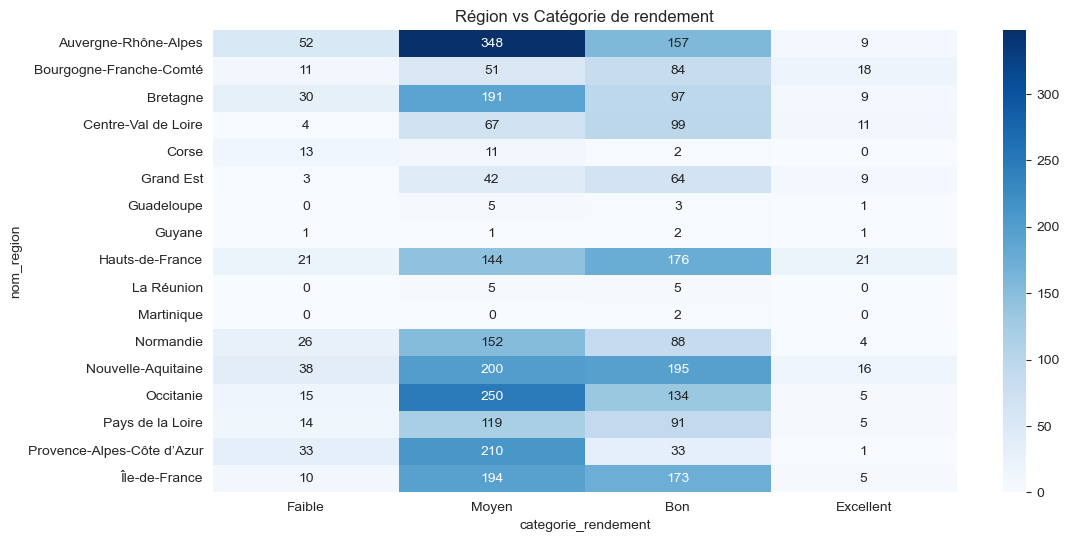

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    table_contingence,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Région vs Catégorie de rendement")
plt.show()

## Régression linéaire : rendement selon prix

In [86]:
from scipy.stats import linregress

result = linregress(
    df["prix_m2"],
    df["rendement_brut"]
)

print("===== REGRESSION LINEAIRE =====")
print("Pente :", round(result.slope, 6))
print("Intercept :", round(result.intercept, 4))
print("R² :", round(result.rvalue**2, 4))
print("p-value :", result.pvalue)

===== REGRESSION LINEAIRE =====
Pente : -0.000603
Intercept : 6.5848
R² : 0.4879
p-value : 0.0


## Graphique Régression Prix / Rendement

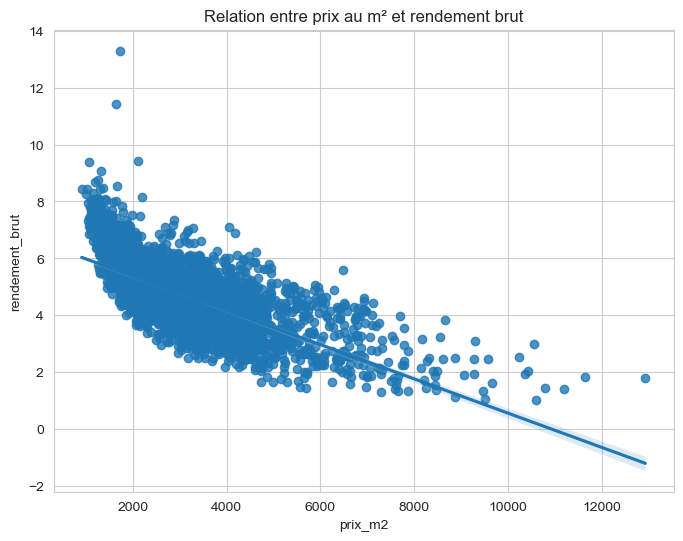

In [87]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="prix_m2",
    y="rendement_brut"
)

plt.title("Relation entre prix au m² et rendement brut")
plt.show()

# Résultats des tests statistiques et interprétation métier

## Hypothèse 1 : Le rendement locatif moyen diffère selon les régions françaises (Test ANOVA)

### Intuition métier

Les régions françaises présentent des caractéristiques économiques et immobilières différentes. Il est donc pertinent de vérifier si les rendements locatifs moyens varient significativement d'une région à l'autre.

### Hypothèses

- **H₀ :** Les rendements locatifs moyens sont égaux entre les régions.
- **H₁ :** Au moins une région présente un rendement locatif moyen différent.

### Résultats

- Statistique F : **22,25**
- p-value : **8,47 × 10⁻⁶³**

### Décision

La p-value est largement inférieure au seuil de significativité de 5 % (0,05).

➡️ **L'hypothèse nulle H₀ est rejetée.**

### Interprétation métier

Les différences observées entre les rendements locatifs des régions françaises sont statistiquement significatives.

Cela signifie que :

- Certaines régions offrent des rendements locatifs plus élevés que d'autres.
- La localisation géographique constitue un facteur déterminant dans la rentabilité d'un investissement immobilier.
- Un investisseur doit intégrer le critère régional dans sa stratégie de sélection des villes les plus attractives.

---

## Hypothèse 2 : Test du Chi²

Ce test permet de déterminer si deux variables qualitatives sont liées ou indépendantes.

La région influence-t-elle la catégorie de rendement d'un investissement immobilier ?

### Intuition métier

Les logements situés dans les villes les plus chères sont généralement loués plus cher. Cette hypothèse vise à mesurer l'intensité de cette relation.

### Hypothèses

- **H₀ :** La région et la catégorie de rendement sont indépendantes.
- **H₁ :** La région et la catégorie de rendement sont dépendantes.

#### Variables utilisées

nom_region (catégorielle)

categorie_rendement (Faible / Moyen / Bon)

### Résultats

| Indicateur        | Valeur       |
| ----------------- | ------------ |
| Chi²              | 432,19       |
| Degrés de liberté | 48           |
| p-value           | 3,04 × 10⁻⁶³ |


### Décision

La p-value est largement inférieure au seuil de significativité de 5 % (0,05).

➡️ **L'hypothèse nulle H₀ est rejetée.**

### Interprétation métier

Les résultats montrent que la région et la catégorie de rendement ne sont pas indépendantes.

Autrement dit :

La localisation régionale influence significativement le niveau de rentabilité observé.
Certaines régions regroupent davantage de villes à rendement élevé.
D'autres régions présentent principalement des rendements moyens ou faibles.
Implication pour l'investisseur

Le choix de la région constitue un critère stratégique dans la recherche d'un investissement locatif rentable.

Un investisseur ne doit donc pas analyser uniquement :

le prix au m² ;
le niveau des loyers ;

mais également :

la dynamique régionale ;
la répartition des catégories de rendement.

La région apparaît comme un facteur déterminant dans l'identification des villes les plus attractives pour investir.

---

## Hypothèse 3 : Le prix au m² influence-t-il le rendement locatif ? (Régression linéaire)

### Intuition métier

Le rendement locatif dépend directement du rapport entre le loyer perçu et le prix d'acquisition du bien. Cette analyse vise à mesurer l'impact du prix immobilier sur la rentabilité.

### Hypothèses

- **H₀ :** Il n'existe pas de relation linéaire entre le prix au m² et le rendement brut.
- **H₁ :** Le rendement brut dépend du prix au m².

### Résultats

- Pente de la régression : **-0,000603**
- Coefficient de détermination (R²) : **0,488**
- p-value : **< 0,001**

### Décision

La p-value est inférieure au seuil de 5 %.

➡️ **L'hypothèse nulle H₀ est rejetée.**

### Interprétation métier

La pente négative de la droite de régression montre qu'une augmentation du prix au m² est associée à une diminution du rendement locatif.

Le coefficient de détermination **R² = 48,8 %** indique que près de la moitié de la variation du rendement brut est expliquée par le prix au m².

Concrètement :

- Les villes les plus chères offrent généralement des rendements locatifs plus faibles.
- Les marchés immobiliers fortement valorisés ne sont pas nécessairement les plus rentables pour un investisseur.
- Les meilleures opportunités d'investissement se situent souvent dans des villes où les prix restent modérés tout en conservant des loyers attractifs.

---

# Conclusion générale

Les analyses statistiques montrent que la localisation géographique et le prix au m² influencent significativement la rentabilité d'un investissement immobilier. 

Les rendements locatifs varient selon les régions et les villes les plus chères ne sont pas nécessairement les plus rentables.

### Recommandation pour l'investisseur

Pour optimiser la rentabilité de son investissement, il est recommandé de privilégier les villes offrant le meilleur équilibre entre prix d'acquisition modéré et niveau de loyer attractif, tout en tenant compte des spécificités régionales du marché immobilier.

In [88]:
df.head()

,ville,departement,code_region,nom_region,prix_m2,prix_estime,loyer_m2,loyer_annuel,rendement_brut,categorie_rendement,score_investissement,nombre_transactions
0,Abbaretz,44,52,Pays de la Loire,1749.354128,87467.706413,8.814289,5288.573423,6.046315,Bon,0.103689,30
1,Abbeville,80,32,Hauts-de-France,2105.698107,105284.905356,8.832116,5299.269419,5.033266,Bon,0.800753,335
2,Ablis,78,11,Île-de-France,2602.416398,130120.819895,10.593604,6356.162211,4.884816,Moyen,0.060065,32
3,Ablon-Sur-Seine,94,11,Île-de-France,3279.097672,163954.883585,16.226343,9735.806061,5.938101,Bon,0.110465,61
4,Abondance,74,84,Auvergne-Rhône-Alpes,4399.576642,219978.832086,14.455576,8673.345536,3.942809,Moyen,0.038536,43


In [89]:
df.to_csv(
    "investissement_immobilier_france.csv",
    index=False,
    encoding="utf-8-sig"
)